In [54]:
#Imports 
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from IPython.display import clear_output, display

In [76]:
# Data loading
path = "Data/FROG Data/frog_01282026.dat"

# Load Header
with open(path) as f:
    header = f.readline().split()

Nt_raw   = int(header[0])      # Number of delay points
Nw_raw   = int(header[1])      # Number of spectral pixels
dt_raw   = float(header[2])    # Delay step (fs)
dlam     = float(header[3])    # Wavelength step (nm)
lam0     = float(header[4])    # Center (or starting) wavelength (nm)

print(f"LOADED: Nt={Nt_raw}, Nw={Nw_raw}, dt={dt_raw} fs, dλ={dlam} nm, λ0={lam0} nm")

# Load Intensity Data
I_raw = np.loadtxt(path, skiprows=1)

LOADED: Nt=256, Nw=56, dt=10.0 fs, dλ=0.452235 nm, λ0=512.951638 nm


In [77]:
# --- ORIENTATION FIX and data processing ---
# We require the matrix shape to be (Nt, Nw) where:
# Rows (axis 0) = Delay
# Cols (axis 1) = Wavelength
# If the file is (Nw, Nt), we transpose it.
if I_raw.shape[0] != Nt_raw and I_raw.shape[1] == Nt_raw:
    print("Transposing input data to match (Delay x Wavelength)...")
    I_raw = I_raw.T
elif I_raw.shape == (Nt_raw, Nw_raw):
    print("Input orientation looks correct (Delay x Wavelength).")
else:
    print(f"Warning: Data shape {I_raw.shape} does not match header {Nt_raw}x{Nw_raw}.")

# Raw Delay Axis
taus_raw = (np.arange(Nt_raw) - Nt_raw // 2) * dt_raw

# Raw Wavelength/Frequency Axis
c = 299.792458 # nm/fs

# Build wavelength axis in nm using the header's center wavelength (lam0) and step (dlam)
lam_axis_raw = lam0 + (np.arange(Nw_raw) - Nw_raw // 2) * dlam 

# Calculate frequency
# Since c is in nm/fs and lam_axis_raw is in nm, c / lam gives 1/fs (PHz) directly.
freq_axis_raw = c / lam_axis_raw # PHz
omega_axis_raw = 2 * np.pi * freq_axis_raw # rad/fs

Input orientation looks correct (Delay x Wavelength).


Resampling to 128x128 Fourier Grid...


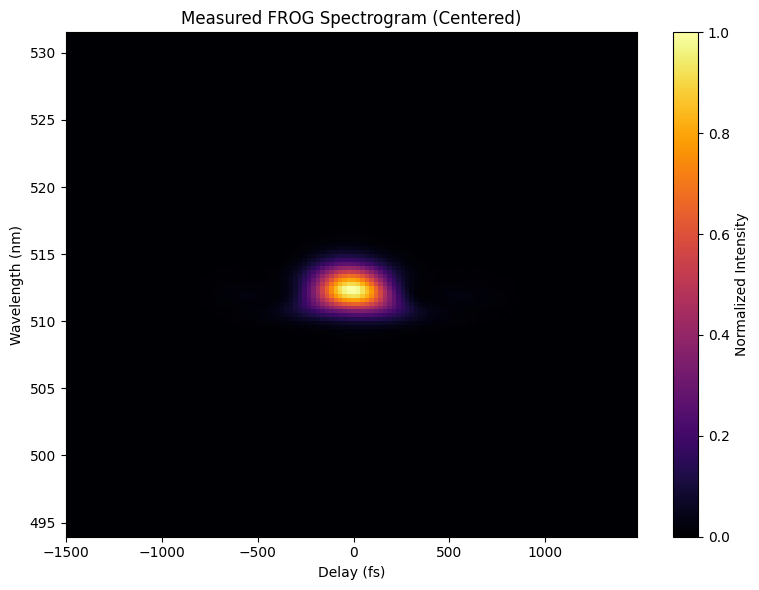

In [78]:

# FROG requires dt * dw = 2pi/N. We interpolate onto a square N x N grid.
N = 128 # Grid size (Power of 2 for fast FFT)
c_nm_fs = 299.792458 # Speed of light in nm/fs
print(f"Resampling to {N}x{N} Fourier Grid...")

# --- 1. Find the actual center of the pulse in the raw data ---
# Marginal spectrum (sum over all delays)
marginal_w = np.sum(I_raw, axis=0) 
w_center = omega_axis_raw[np.argmax(marginal_w)] 

# Marginal delay (sum over all frequencies)
marginal_tau = np.sum(I_raw, axis=1)
tau_center = taus_raw[np.argmax(marginal_tau)]

# Shift the raw delay axis so the pulse peak is perfectly at 0 fs
taus_raw_centered = taus_raw - tau_center 

# --- 2. Define New Frequency Grid (Linear in Omega) ---
# Ensure we capture enough bandwidth (1.5x padding)
w_span = (np.max(omega_axis_raw) - np.min(omega_axis_raw)) * 1.5 
w_grid = np.linspace(w_center - w_span/2, w_center + w_span/2, N)
dw = w_grid[1] - w_grid[0]

# --- 3. Define Reciprocal Time Grid ---
# This satisfies the Fourier constraint dt * dw = 2*pi / N
dt = (2 * np.pi) / (N * dw)
t_grid = (np.arange(N) - N//2) * dt
# In SHG FROG, the delay step must match the time step for the FFT
delay_grid = t_grid 

# --- 4. Interpolate Data onto New Grid ---
# We want Rows = Delay, Cols = Frequency

# Step A: Interpolate Wavelengths (Cols) -> Linear Frequency
Nt_raw = I_raw.shape[0]
I_temp = np.zeros((Nt_raw, N))
for i in range(Nt_raw):
    # Sort indices to ensure omega is ascending for interp1d
    sort_idx = np.argsort(omega_axis_raw)
    interp_w = interp1d(omega_axis_raw[sort_idx], I_raw[i, sort_idx], 
                        kind='linear', bounds_error=False, fill_value=0)
    I_temp[i, :] = interp_w(w_grid)

# Step B: Interpolate Delay (Rows) -> Linear Time
FROG_meas = np.zeros((N, N))
for j in range(N):
    # Use the centered raw delay axis here
    interp_tau = interp1d(taus_raw_centered, I_temp[:, j], 
                          kind='linear', bounds_error=False, fill_value=0)
    FROG_meas[:, j] = interp_tau(delay_grid)

# --- 5. Normalize & Background Subtraction ---
bg = np.median(np.concatenate((FROG_meas[:5, :], FROG_meas[-5:, :])))
FROG_meas -= bg
FROG_meas[FROG_meas < 0] = 0
FROG_meas /= np.max(FROG_meas)

# Constraint Amplitude (The algorithm usually works on the E-field magnitude)
A_meas = np.sqrt(FROG_meas)

# --- 6. Convert Frequency Axis to Wavelength for Plotting ---
# lambda = 2*pi*c / omega
lambda_grid = (2 * np.pi * c_nm_fs) / w_grid

# --- 7. Check Interpolation (Visualization) ---
plt.figure(figsize=(8, 6))

# Use pcolormesh because the wavelength grid is non-linear
# Shading='auto' handles the coordinates correctly.
# Transpose FROG_meas (.T) so Delay maps to X and Wavelength maps to Y.
plt.pcolormesh(delay_grid, lambda_grid, FROG_meas.T, cmap='inferno', shading='auto')

plt.title("Measured FROG Spectrogram (Centered)")
plt.xlabel("Delay (fs)")
plt.ylabel("Wavelength (nm)")
plt.colorbar(label="Normalized Intensity")

plt.tight_layout()
plt.show()

----------------------------------------
Autocorrelation FWHM:          342.43 fs
Estimated Pulse FWHM (Sech^2):   221.93 fs
----------------------------------------


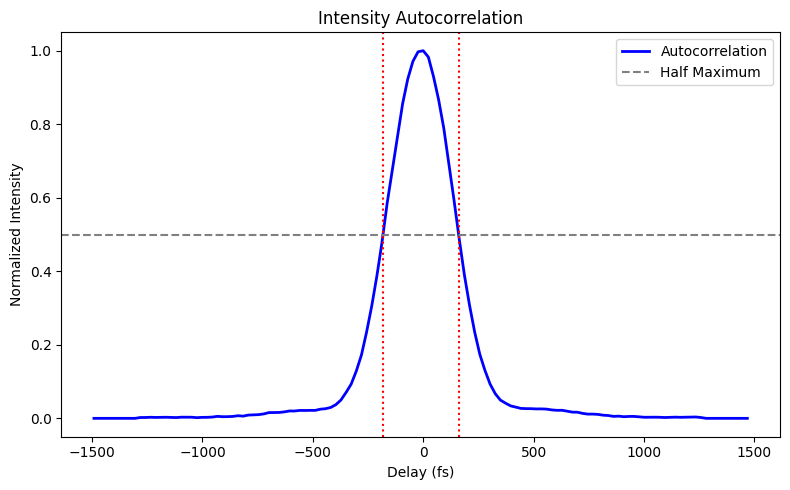

In [79]:
# We can look at the intensity autocorrelation as a sanity check to find the pulse duration of our laser

# Sum the FROG trace along the frequency axis (axis=1) to get the autocorrelation
autocorrelation = np.sum(FROG_meas, axis=1)

# Normalize the autocorrelation so the peak is at 1
autocorrelation /= np.max(autocorrelation)

#1. To find the pulse duration we need to find the FWHM 
# Subtract 0.5 from the normalized data to find where it crosses zero (the half-max points)
spline = UnivariateSpline(delay_grid, autocorrelation - 0.5, s=0)
roots = spline.roots()

# Assuming a clean peak, the roots give us the exact left and right half-max crossings
if len(roots) >= 2:
    fwhm_ac = roots[-1] - roots[0]
else:
    # Fallback to simple array indexing if spline somehow fails to find roots
    above_half = np.where(autocorrelation >= 0.5)[0]
    fwhm_ac = delay_grid[above_half[-1]] - delay_grid[above_half[0]]

# 2. Estimate the actual Pulse Duration

pulse_duration_sech2 = fwhm_ac / 1.543          # Deconvolution for Sech^2

# 3. Print the results
print("-" * 40)
print(f"Autocorrelation FWHM:          {fwhm_ac:.2f} fs")

print(f"Estimated Pulse FWHM (Sech^2):   {pulse_duration_sech2:.2f} fs")
print("-" * 40)

# Optional: Add the FWHM lines to your previous plot to verify visually
plt.figure(figsize=(8, 5))
plt.plot(delay_grid, autocorrelation, color='blue', linewidth=2, label="Autocorrelation")

# Plot horizontal line at half-max and vertical lines at the roots
plt.axhline(0.5, color='gray', linestyle='--', label="Half Maximum")
if len(roots) >= 2:
    plt.axvline(roots[0], color='red', linestyle=':')
    plt.axvline(roots[-1], color='red', linestyle=':')
    
plt.title("Intensity Autocorrelation")
plt.xlabel("Delay (fs)")
plt.ylabel("Normalized Intensity")
plt.legend()

plt.tight_layout()
plt.show()

In [80]:


# Generate random-seeded guess as shown in the FROG GP algorithim chart
E_guess = np.exp(-0.5 * ((t_grid - pulse_duration_sech2)/(pulse_duration_sech2))**2).astype(np.complex128)
# Made the noise complex to properly seed the phase search
E_guess += 0.05 * (np.random.randn(N) + 1j * np.random.randn(N)) 
E_guess /= np.max(np.abs(E_guess)) # Normalize initial guess


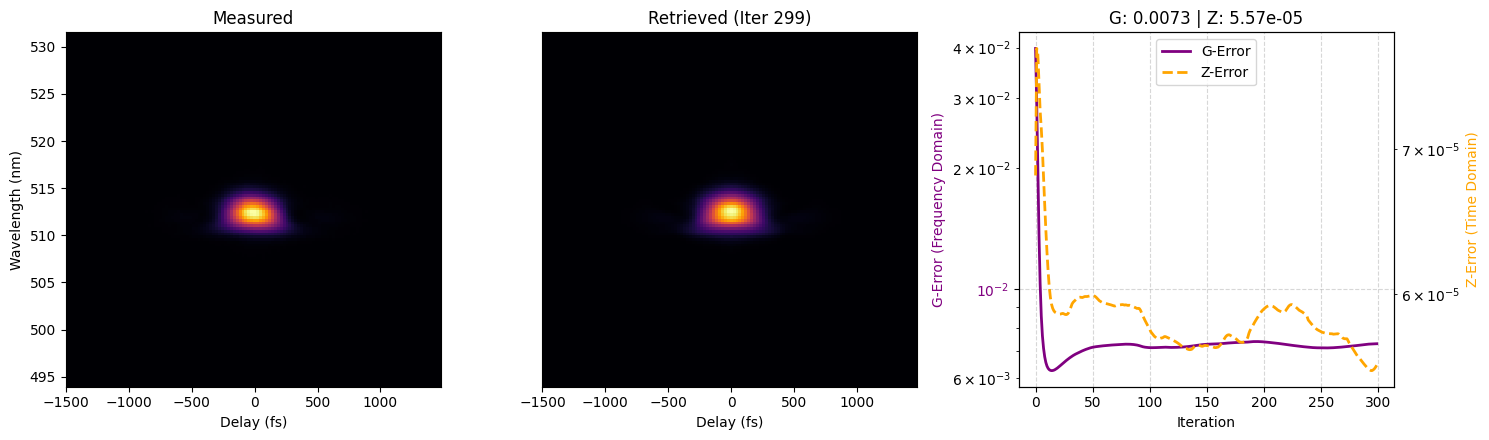

In [81]:
#GP Algorithim 
n_iter = 300
errors = []
z_errors = []

print("Starting Retrieval Loop...")
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

# Create the twin axis for the Z-error outside the loop
ax2_z = ax[2].twinx()

for k in range(n_iter):
    
    # Generate Signal Matrix Sig(tau, t) for SHG 
    Sig_t = np.zeros((N, N), dtype=np.complex128)
    for i in range(N):
        shift = i - N//2
        E_shifted = np.roll(E_guess, shift)
        Sig_t[i, :] = E_guess * E_shifted  #E_sig(t, tau) = E(t) * E(t - tau).
        
    # FT E_sig(t, tau) into E_sig(w, tau). This creates our "guessed" FROG trace.
    Sig_w = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(Sig_t, axes=1), axis=1), axes=1) # fftshift is used to keep the zero-frequency component centered.

    # Apply the Experimental Data Constraint & Calculate G-Error
    
    current_amp = np.abs(Sig_w)
    
    I_meas = A_meas**2 # Measured data
    I_rec = current_amp**2 #Guessed/reconstructed pulse
    scale_G = np.sum(I_meas * I_rec) / (np.sum(I_rec**2) + 1e-10)  #Compare the magntiude of our guessed pulse with the measured data(A_meas)
    err = np.sqrt(np.mean((I_meas - scale_G * I_rec)**2))  # We calculate the G-Error (RMS difference) to track convergence.
    errors.append(err)

    # Apply data
    current_amp[current_amp < 1e-10] = 1e-10 
    Sig_w_new = Sig_w * (A_meas / current_amp) #Force the amplitude of our guess to match the experimental

    # 4. Inverse FFT back to Time Domain
    Sig_t_new = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(Sig_w_new, axes=1), axis=1), axes=1) #new, modified E_sig(t, tau).

    # 5. Update Electric Field (SHG Projection)
    
    E_new_num = np.zeros(N, dtype=np.complex128)
    E_new_den = np.zeros(N, dtype=np.float64)
    
    # The modified 2D signal matrix no longer strictly obeys the mathematical
    # rules of SHG. We must project it back down to a 1D electric field E(t)
    # by minimizing the mathematical distance. This is done by integrating
    # (summing) the signal matrix across the delay axis (tau).
    
    for i in range(N):
        shift = i - N//2
        E_shifted_conj = np.conj(np.roll(E_guess, shift))
        E_new_num += Sig_t_new[i, :] * E_shifted_conj
        E_new_den += np.abs(E_shifted_conj)**2
        
    E_new = E_new_num / (E_new_den + 1e-10) 
    
    # 6. Normalizing the updated electric field
    E_new /= np.max(np.abs(E_new))
    
    # 7. Calculate the Z-Error (Time Domain Error)
    Sig_t_physical = np.zeros((N, N), dtype=np.complex128)
    for i in range(N):
        shift = i - N//2
        Sig_t_physical[i, :] = E_new * np.roll(E_new, shift)
    # We take our brand new E(t) and build a strict SHG mathematical matrix from it.
    I_math = np.abs(Sig_t_new)**2
    I_phys = np.abs(Sig_t_physical)**2
    scale_Z = np.sum(I_math * I_phys) / (np.sum(I_phys**2) + 1e-10)
    z_err = np.sqrt(np.mean((I_math - scale_Z * I_phys)**2)) #We compare this purely mathematical matrix against the modified "experimental" matrix from Step 4. If this error is high, the field is not physically valid.
    z_errors.append(z_err)

    # Momentum update
    # Instead of completely replacing our old guess with the new calculation,
    # we blend them 50/50. This prevents wild oscillations and keeps the 
    # algorithm mathematically stable as it converges.
    E_guess = 0.5 * E_new + 0.5 * E_guess

    # 8. Live Plotting
    if k % 5 == 0 or k == n_iter - 1:
        # Clear both primary and twin axes
        ax[0].clear()
        ax[1].clear()
        ax[2].clear()
        ax2_z.clear()
        
        # --- Plot A: Measured Trace ---
        ax[0].pcolormesh(delay_grid, lambda_grid, (A_meas**2).T, cmap='inferno', shading='auto')
        ax[0].set_title("Measured")
        ax[0].set_xlabel("Delay (fs)")
        ax[0].set_ylabel("Wavelength (nm)")
        
        # --- Plot B: Retrieved Trace ---
        Rec_trace = np.abs(Sig_w)**2
        Rec_trace /= np.max(Rec_trace) 
        ax[1].pcolormesh(delay_grid, lambda_grid, Rec_trace.T, cmap='inferno', shading='auto')
        ax[1].set_title(f"Retrieved (Iter {k})")
        ax[1].set_xlabel("Delay (fs)")
        ax[1].set_yticks([]) 
        
        # --- Plot C: G-Error
        ax[2].plot(range(len(errors)), errors, color='purple', linewidth=2, label='G-Error')
        ax[2].set_ylabel("G-Error (Frequency Domain)", color='purple')
        ax[2].tick_params(axis='y', labelcolor='purple')
        ax[2].set_yscale('log')
        ax[2].set_xlabel("Iteration")
        ax[2].grid(True, linestyle='--', alpha=0.5)

        # --- Plot D: Z-Error 
        ax2_z.plot(range(len(z_errors)), z_errors, color='orange', linewidth=2, linestyle='--', label='Z-Error')
        ax2_z.set_ylabel("Z-Error (Time Domain)", color='orange')
        
        # FORCE Matplotlib to put this back on the right side!
        ax2_z.yaxis.set_label_position("right")
        ax2_z.yaxis.tick_right()
        
        ax2_z.tick_params(axis='y', labelcolor='orange')
        ax2_z.set_yscale('log')

        # Combine legends from both axes
        lines_1, labels_1 = ax[2].get_legend_handles_labels()
        lines_2, labels_2 = ax2_z.get_legend_handles_labels()
        ax[2].legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center')

        ax[2].set_title(f"G: {err:.4f} | Z: {z_err:.2e}")
        
        plt.tight_layout()
        clear_output(wait=True)
        display(fig)

plt.close(fig)


FINAL FWHM (Array Measurement): 233.06 fs


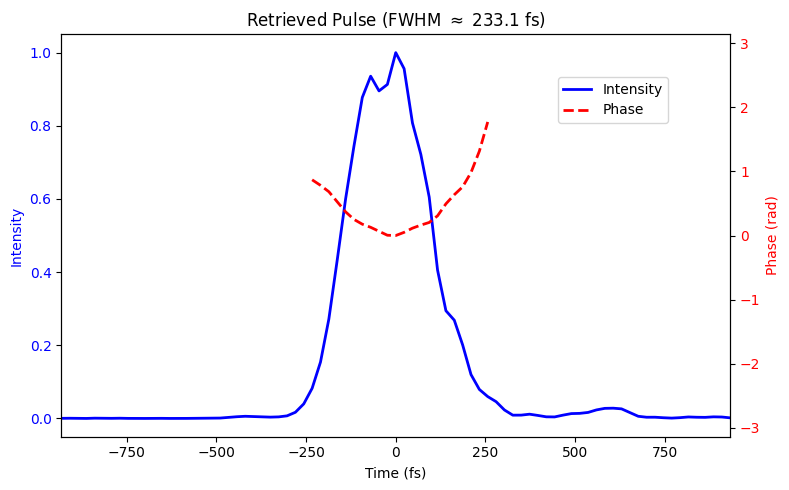

In [82]:
# --- A. Final Pulse Processing ---
# 1. Get raw intensity to use as a weight
Intensity_raw = np.abs(E_guess)**2
Intensity_raw /= np.max(Intensity_raw)

# 2. Get raw phase
raw_phase = np.unwrap(np.angle(E_guess))

# Weight the linear fit by intensity so noise in the tails is ignored
p = np.polyfit(t_grid, raw_phase, 1, w=Intensity_raw)

# Remove linear phase slope (carrier frequency offset)
E_final = E_guess * np.exp(-1j * (p[0]*t_grid + p[1]))

# --- NEW: Center the pulse in time ---
peak_idx = np.argmax(np.abs(E_final)**2)
center_idx = len(t_grid) // 2
shift_needed = center_idx - peak_idx

# Roll the array so the peak is exactly in the middle
E_final = np.roll(E_final, shift_needed)
# -------------------------------------

# Calculate Final Intensity and Phase
Intensity = np.abs(E_final)**2
Intensity /= np.max(Intensity)
Phase = np.unwrap(np.angle(E_final))

# Center the phase so it equals exactly 0 at the peak intensity (now at center_idx)
Phase -= Phase[center_idx]

# Calculate FWHM directly from the data points
above_half = np.where(Intensity >= 0.5)[0]
if len(above_half) > 0:
    fwhm_res = t_grid[above_half[-1]] - t_grid[above_half[0]]
else:
    fwhm_res = 0

print(f"\nFINAL FWHM (Array Measurement): {fwhm_res:.2f} fs")

# --- B. Plot 1: Pulse Intensity & Phase ---
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(t_grid, Intensity, 'b-', linewidth=2, label='Intensity')
ax1.set_xlabel('Time (fs)')
ax1.set_ylabel('Intensity', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Dynamically zoom in on the pulse based on its width
ax1.set_xlim([-fwhm_res * 4, fwhm_res * 4]) 

ax2 = ax1.twinx()

# Mask phase where intensity is low (5% is a safe threshold)
phase_plot = Phase.copy()
phase_plot[Intensity < 0.05] = np.nan

ax2.plot(t_grid, phase_plot, 'r--', linewidth=2, label='Phase')
ax2.set_ylabel('Phase (rad)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Lock the phase y-axis limits so a random spike doesn't squash the whole plot
ax2.set_ylim([-np.pi, np.pi])

plt.title(f'Retrieved Pulse (FWHM $\\approx$ {fwhm_res:.1f} fs)')
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.85))

plt.tight_layout()
plt.show()

